In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from itertools import combinations

In [2]:
# -------------------------------
# Load your sampled pickle file
# -------------------------------
with open("full_linked_diagnosis_data.pkl", "rb") as f:
    diagnosis_data = pickle.load(f)

In [4]:
# -------------------------------
# Count UMLS canonical names and collect mapping scores
# -------------------------------
canonical_name_counter = Counter()
cui_score_list = []

for diag_dict in diagnosis_data.values():
    for cuis in diag_dict.values():
        for cui_info in cuis:
            canonical_name = cui_info["name"]
            canonical_name_counter[canonical_name] += 1
            cui_score_list.append(cui_info["score"])


In [8]:
# -------------------------------
# Remove noisy or survey-style entries
# -------------------------------
filtered_canonical_counter = canonical_name_counter.copy()
to_remove = [name for name in canonical_name_counter if "ever told you" in name.lower() or ":" in name.lower()]
for name in to_remove:
    del filtered_canonical_counter[name]

In [9]:
len(filtered_canonical_counter)

46615

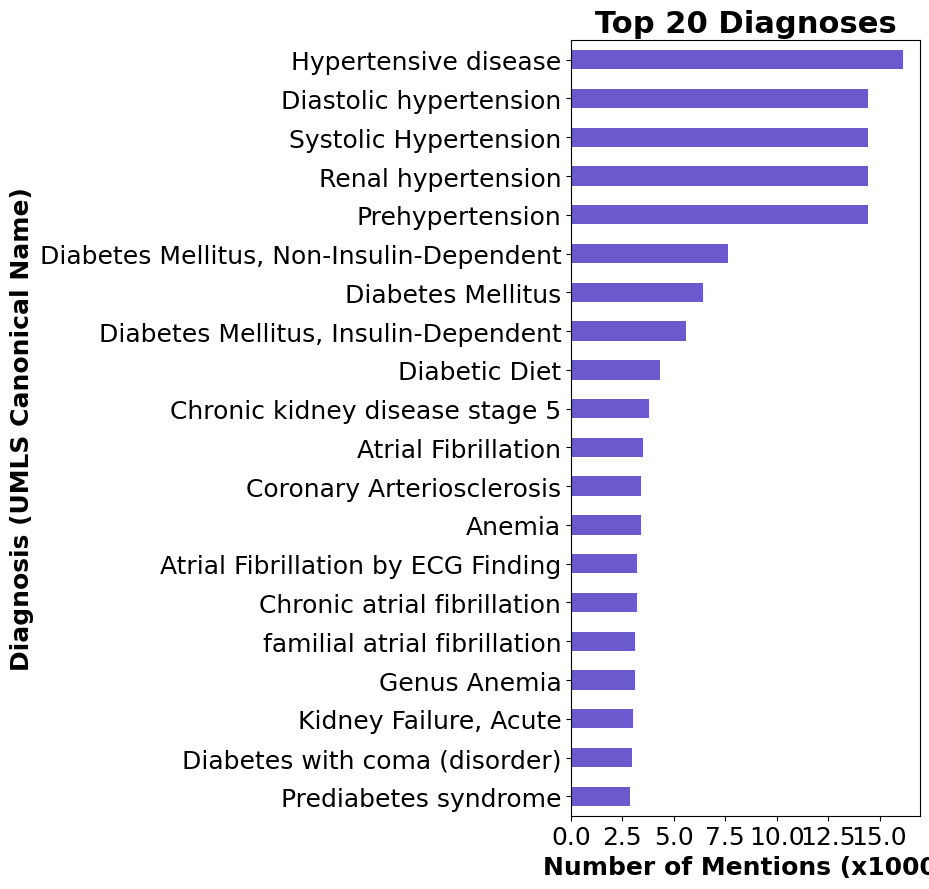

In [10]:
# -------------------------------
# Bar Plot: Top 20 UMLS Canonical Diagnoses
# -------------------------------
import matplotlib.pyplot as plt
import pandas as pd

# Prepare the data
top_canonical_df = pd.DataFrame(
    filtered_canonical_counter.most_common(20),
    columns=["Diagnosis (UMLS Canonical Name)", "Count"]
)

# Sort the DataFrame by Count
top_canonical_df = top_canonical_df.sort_values(by="Count")
top_canonical_df['Count'] /= 1000

# Create figure and axis
fig, ax = plt.subplots(figsize=(9.4, 9))

# Create the horizontal bar plot
top_canonical_df.plot(
    kind='barh',
    x='Diagnosis (UMLS Canonical Name)',
    y='Count',
    legend=False,
    color='slateblue',
    ax=ax,
    fontsize=18,
)

# Customize the plot
ax.set_title('Top 20 Diagnoses', fontsize=22, fontweight='bold')
ax.set_xlabel('Number of Mentions (x1000)', fontsize=18, fontweight='bold')
ax.set_ylabel('Diagnosis (UMLS Canonical Name)', fontsize=18, fontweight='bold')
plt.tight_layout()

# Save the figure
fig.savefig("top_diagnoses_umls.pdf", dpi=300)
# plt.close(fig)  # Optional: close to free memory


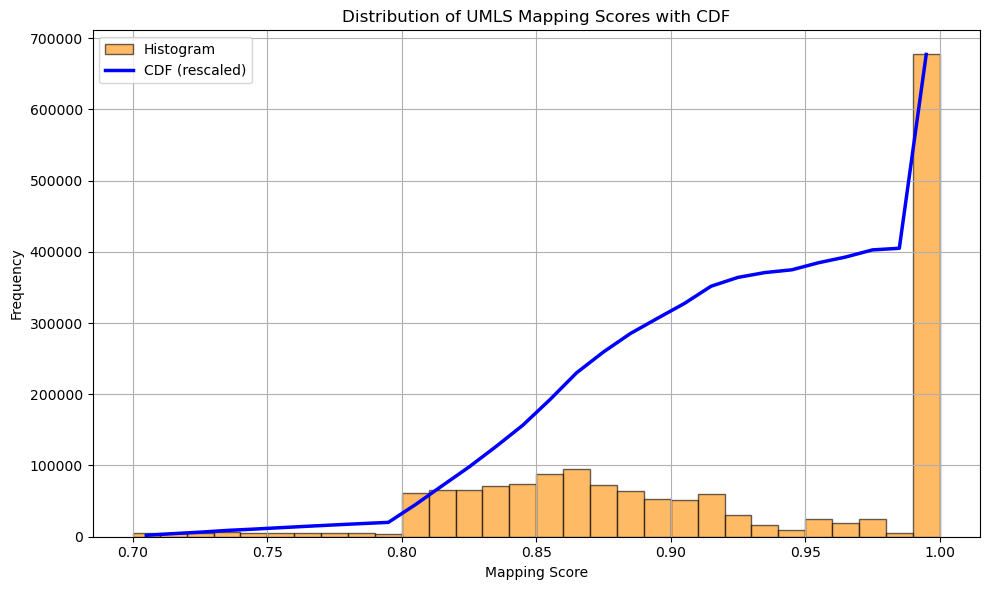

In [11]:
# -------------------------------
# Histogram with CDF overlay: UMLS Mapping Scores
# -------------------------------
plt.figure(figsize=(10, 6))
counts, bins, _ = plt.hist(cui_score_list, bins=30, edgecolor='black', color='darkorange', alpha=0.6, label='Histogram')
cdf = np.cumsum(counts) / sum(counts)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
plt.plot(bin_centers, cdf * max(counts), color='blue', linewidth=2.5, label='CDF (rescaled)')
plt.title('Distribution of UMLS Mapping Scores with CDF')
plt.xlabel('Mapping Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("umls_mapping_score_distribution_with_cdf.png")
# plt.close()

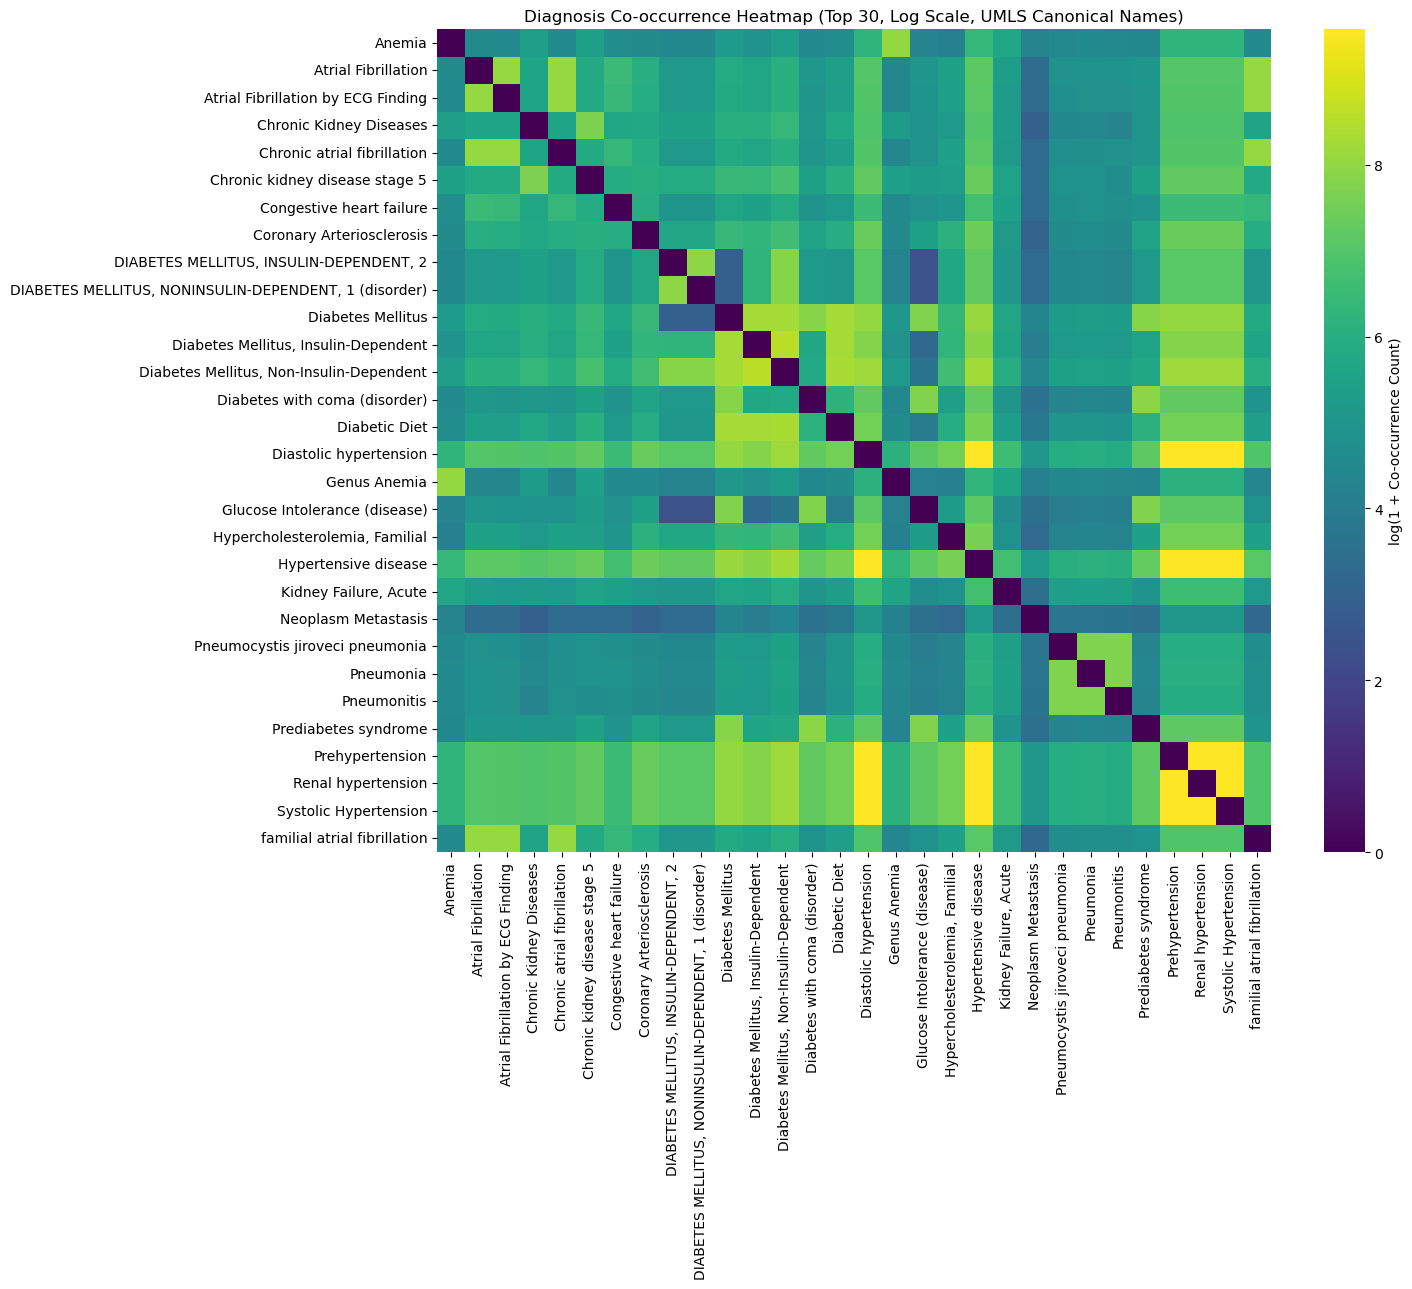

In [12]:
# -------------------------------
# Co-occurrence Heatmap (Top 30) — Log Scale
# -------------------------------
top_k = 30
top_canonical_df_k = pd.DataFrame(filtered_canonical_counter.most_common(top_k), columns=["Diagnosis (UMLS Canonical Name)", "Count"])
canonical_set_k = set(top_canonical_df_k["Diagnosis (UMLS Canonical Name)"])

cooccurrence_counter_k = defaultdict(int)
for diag_dict in diagnosis_data.values():
    canonical_names = []
    for cuis in diag_dict.values():
        canonical_names.extend([cui_info["name"] for cui_info in cuis])
    filtered = [n for n in canonical_names if n in canonical_set_k]
    for d1, d2 in combinations(sorted(set(filtered)), 2):
        cooccurrence_counter_k[(d1, d2)] += 1

canonical_diag_list_k = sorted(canonical_set_k)
cooccurrence_df_k = pd.DataFrame(0, index=canonical_diag_list_k, columns=canonical_diag_list_k)
for (d1, d2), count in cooccurrence_counter_k.items():
    cooccurrence_df_k.loc[d1, d2] = count
    cooccurrence_df_k.loc[d2, d1] = count

plt.figure(figsize=(15, 13))
sns.heatmap(
    np.log1p(cooccurrence_df_k),
    cmap='viridis',
    xticklabels=True,
    yticklabels=True,
    cbar_kws={'label': 'log(1 + Co-occurrence Count)'}
)
plt.title("Diagnosis Co-occurrence Heatmap (Top 30, Log Scale, UMLS Canonical Names)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("cooccurrence_heatmap_top30_logscale.png")
# plt.close()

/home/snoroozi/.local/lib/python3.10/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/snoroozi/.local/lib/python3.10/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


[Text(1, 0.5, 'Hypertensive disease'),
 Text(1, 1.5, 'Renal hypertension'),
 Text(1, 2.5, 'Diastolic hypertension'),
 Text(1, 3.5, 'Systolic Hypertension'),
 Text(1, 4.5, 'Diabetes Mellitus, Non-Insulin-Dependent'),
 Text(1, 5.5, 'Prehypertension'),
 Text(1, 6.5, 'Neoplasm Metastasis'),
 Text(1, 7.5, 'Genus Anemia'),
 Text(1, 8.5, 'Pneumonitis'),
 Text(1, 9.5, 'Diabetes Mellitus'),
 Text(1, 10.5, 'Diabetes Mellitus, Insulin-Dependent'),
 Text(1, 11.5, 'Glucose Intolerance (disease)'),
 Text(1, 12.5, 'DIABETES MELLITUS, NONINSULIN-DEPENDENT, 1 (disorder)'),
 Text(1, 13.5, 'Anemia'),
 Text(1, 14.5, 'Pneumocystis jiroveci pneumonia'),
 Text(1, 15.5, 'Atrial Fibrillation by ECG Finding'),
 Text(1, 16.5, 'DIABETES MELLITUS, INSULIN-DEPENDENT, 2'),
 Text(1, 17.5, 'Diabetic Diet'),
 Text(1, 18.5, 'Chronic atrial fibrillation'),
 Text(1, 19.5, 'Pneumonia'),
 Text(1, 20.5, 'Prediabetes syndrome'),
 Text(1, 21.5, 'Congestive heart failure'),
 Text(1, 22.5, 'Hypercholesterolemia, Familial'),
 Tex

<Figure size 1000x600 with 0 Axes>

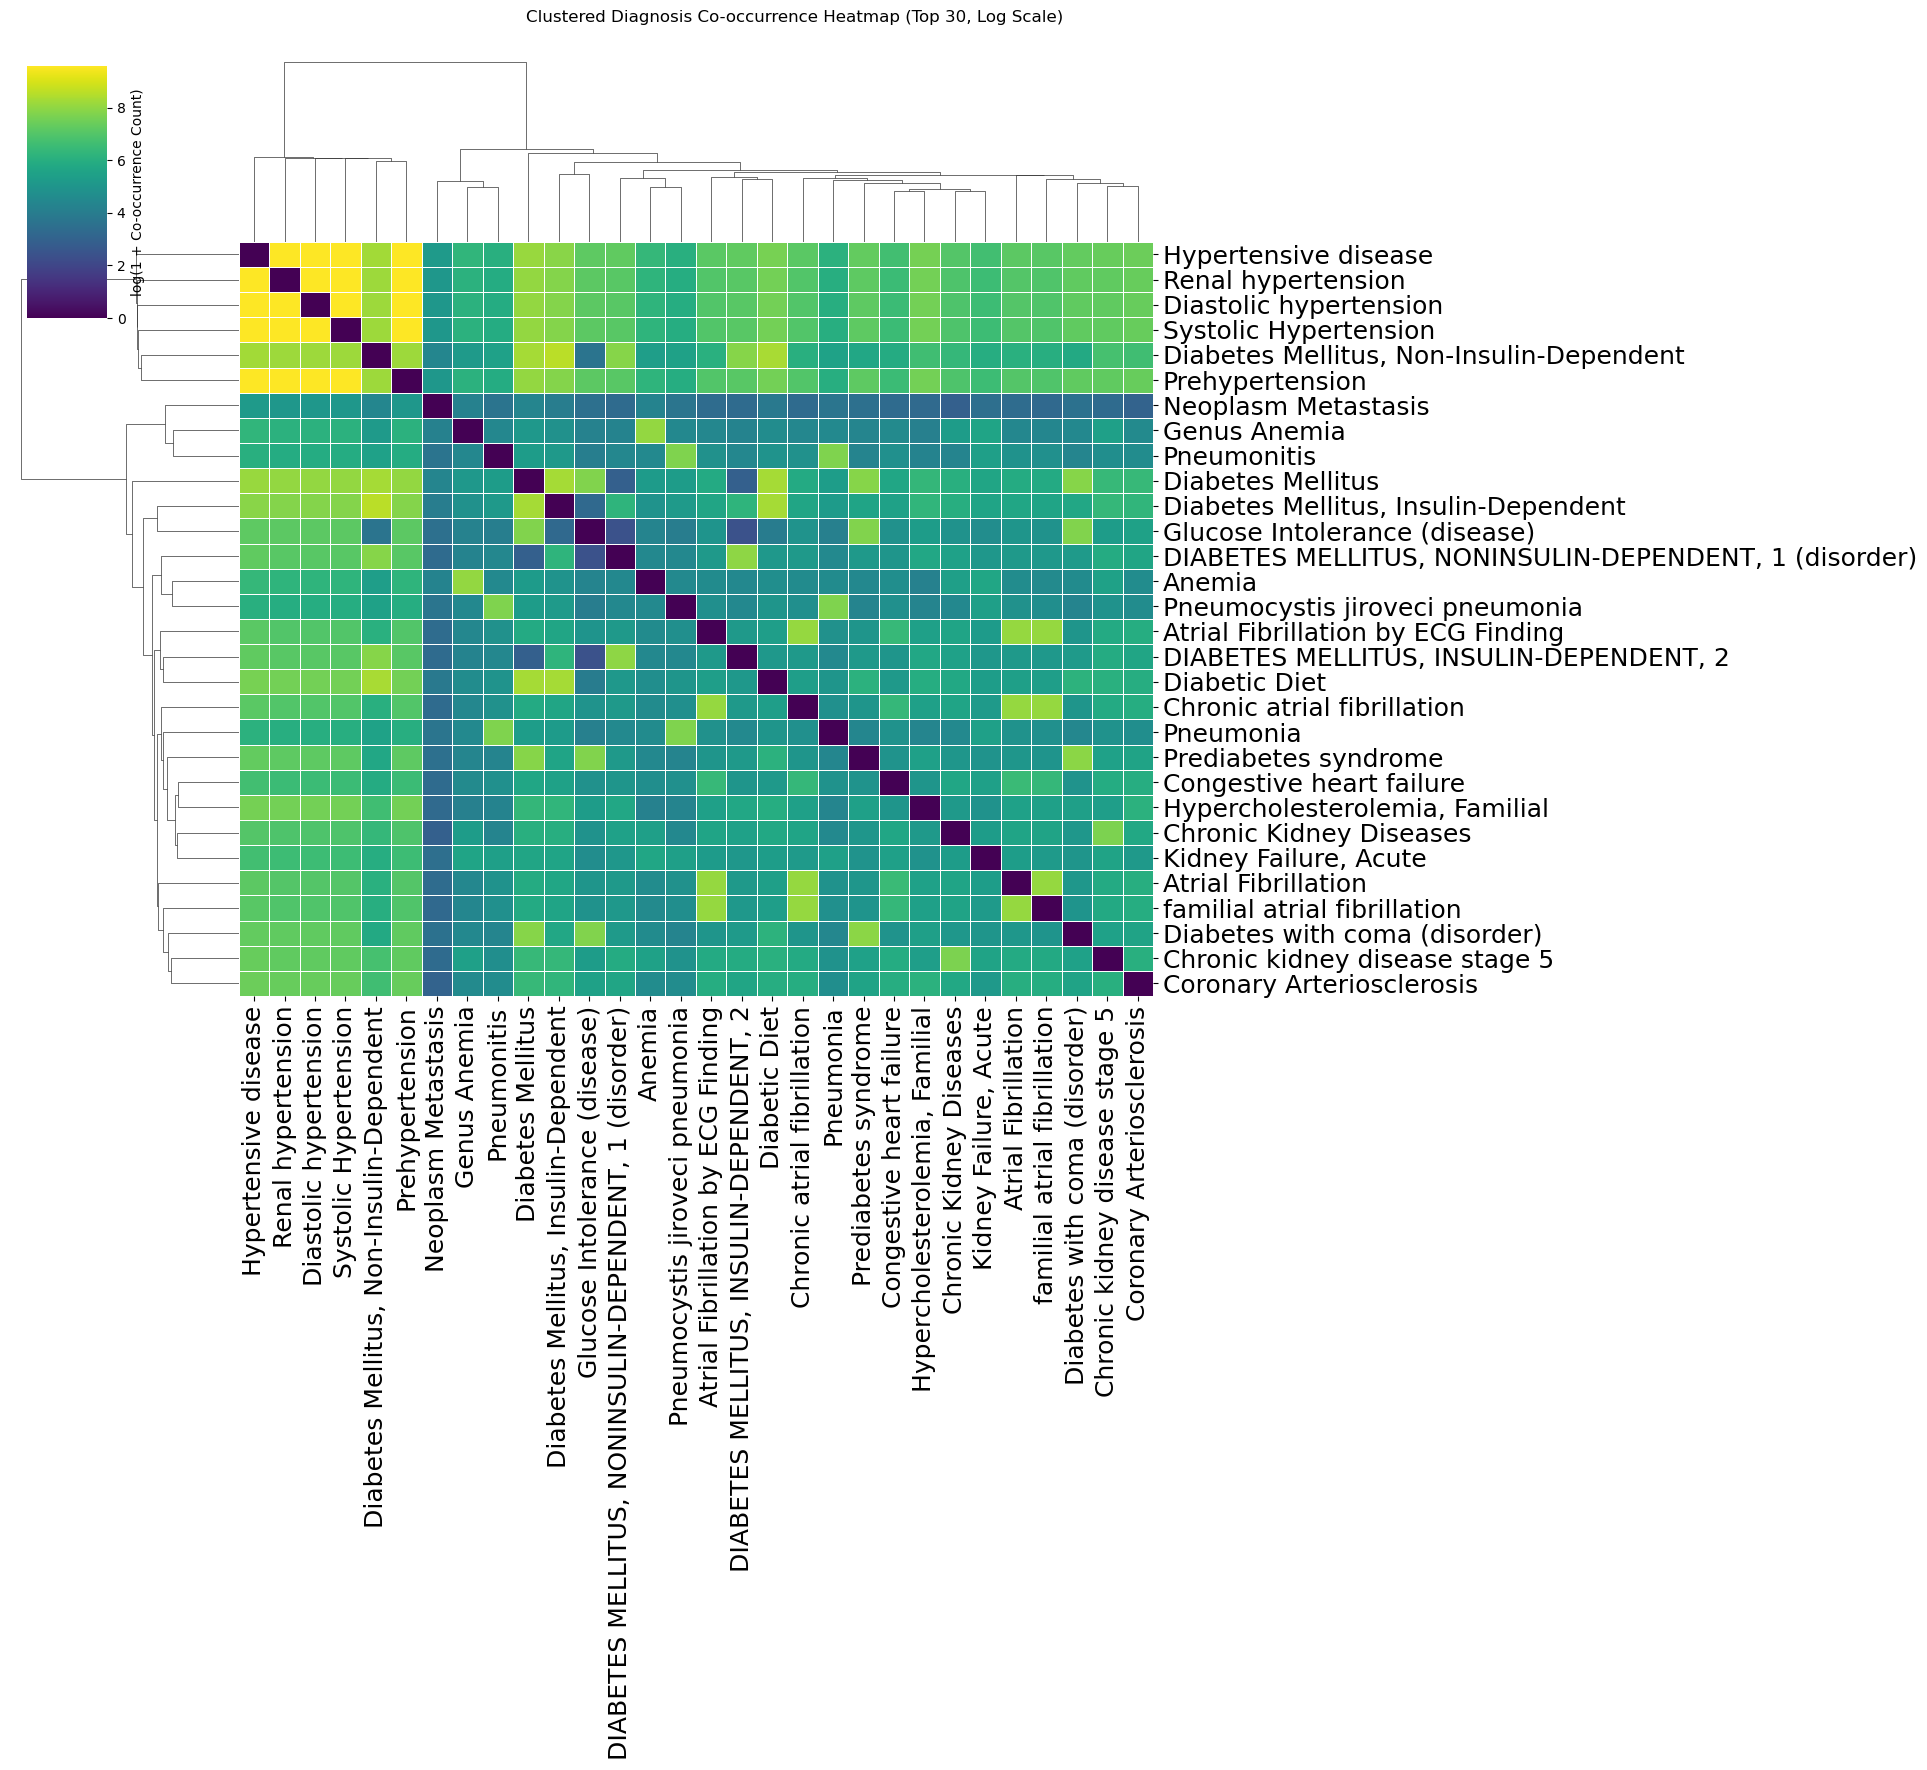

In [ ]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from itertools import combinations

# -------------------------------
# Load your sampled pickle file
# -------------------------------
with open("full_linked_diagnosis_data.pkl", "rb") as f:
    diagnosis_data = pickle.load(f)

# -------------------------------
# Count UMLS canonical names and collect mapping scores
# -------------------------------
canonical_name_counter = Counter()
cui_score_list = []

for diag_dict in diagnosis_data.values():
    for cuis in diag_dict.values():
        for cui_info in cuis:
            canonical_name = cui_info["name"]
            canonical_name_counter[canonical_name] += 1
            cui_score_list.append(cui_info["score"])

# -------------------------------
# Remove noisy or survey-style entries
# -------------------------------
filtered_canonical_counter = canonical_name_counter.copy()
to_remove = [name for name in canonical_name_counter if "ever told you" in name.lower() or ":" in name.lower()]
for name in to_remove:
    del filtered_canonical_counter[name]

# -------------------------------
# Bar Plot: Top 20 UMLS Canonical Diagnoses
# -------------------------------
top_canonical_df = pd.DataFrame(filtered_canonical_counter.most_common(20), columns=["Diagnosis (UMLS Canonical Name)", "Count"])
plt.figure(figsize=(10, 6))
top_canonical_df.sort_values(by="Count").plot(
    kind='barh', x='Diagnosis (UMLS Canonical Name)', y='Count',
    legend=False, color='slateblue'
)
plt.title('Top 20 Diagnoses (UMLS Canonical Names)')
plt.xlabel('Number of Mentions')
plt.tight_layout()
plt.savefig("top_diagnoses_umls.png")
plt.close()

# -------------------------------
# Histogram with CDF overlay: UMLS Mapping Scores
# -------------------------------
plt.figure(figsize=(10, 6))
counts, bins, _ = plt.hist(cui_score_list, bins=30, edgecolor='black', color='darkorange', alpha=0.6, label='Histogram')
cdf = np.cumsum(counts) / sum(counts)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
plt.plot(bin_centers, cdf * max(counts), color='blue', linewidth=2.5, label='CDF (rescaled)')
plt.title('Distribution of UMLS Mapping Scores with CDF')
plt.xlabel('Mapping Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("umls_mapping_score_distribution_with_cdf.png")
plt.close()

# -------------------------------
# Co-occurrence Heatmap (Top 30) — Log Scale
# -------------------------------
top_k = 30
top_canonical_df_k = pd.DataFrame(filtered_canonical_counter.most_common(top_k), columns=["Diagnosis (UMLS Canonical Name)", "Count"])
canonical_set_k = set(top_canonical_df_k["Diagnosis (UMLS Canonical Name)"])

cooccurrence_counter_k = defaultdict(int)
for diag_dict in diagnosis_data.values():
    canonical_names = []
    for cuis in diag_dict.values():
        canonical_names.extend([cui_info["name"] for cui_info in cuis])
    filtered = [n for n in canonical_names if n in canonical_set_k]
    for d1, d2 in combinations(sorted(set(filtered)), 2):
        cooccurrence_counter_k[(d1, d2)] += 1

canonical_diag_list_k = sorted(canonical_set_k)
cooccurrence_df_k = pd.DataFrame(0, index=canonical_diag_list_k, columns=canonical_diag_list_k)
for (d1, d2), count in cooccurrence_counter_k.items():
    cooccurrence_df_k.loc[d1, d2] = count
    cooccurrence_df_k.loc[d2, d1] = count

plt.figure(figsize=(15, 13))
sns.heatmap(
    np.log1p(cooccurrence_df_k),
    cmap='viridis',
    xticklabels=True,
    yticklabels=True,
    cbar_kws={'label': 'log(1 + Co-occurrence Count)'}
)
plt.title("Diagnosis Co-occurrence Heatmap (Top 30, Log Scale, UMLS Canonical Names)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("cooccurrence_heatmap_top30_logscale.png")
plt.close()

# -------------------------------
# Clustered Heatmap (Top 30) — Log Scale
# -------------------------------
log_scaled_matrix = np.log1p(cooccurrence_df_k)
g = sns.clustermap(
    log_scaled_matrix,
    cmap='viridis',
    figsize=(16, 14),
    metric='euclidean',
    method='ward',
    linewidths=0.5,
    cbar_kws={'label': 'log(1 + Co-occurrence Count)'},
)
g.fig.suptitle("Clustered Diagnosis Co-occurrence Heatmap (Top 30, Log Scale)", y=1.02)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=18)  # Increase x-axis tick label font size
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=18)  # Increase y-axis tick label font size
g.savefig("clustered_cooccurrence_heatmap_top30.pdf")

/home/snoroozi/.local/lib/python3.10/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/snoroozi/.local/lib/python3.10/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


Text(0.5, 1.02, 'Clustered Diagnosis Co-occurrence Heatmap (Top 30, Log Scale)')

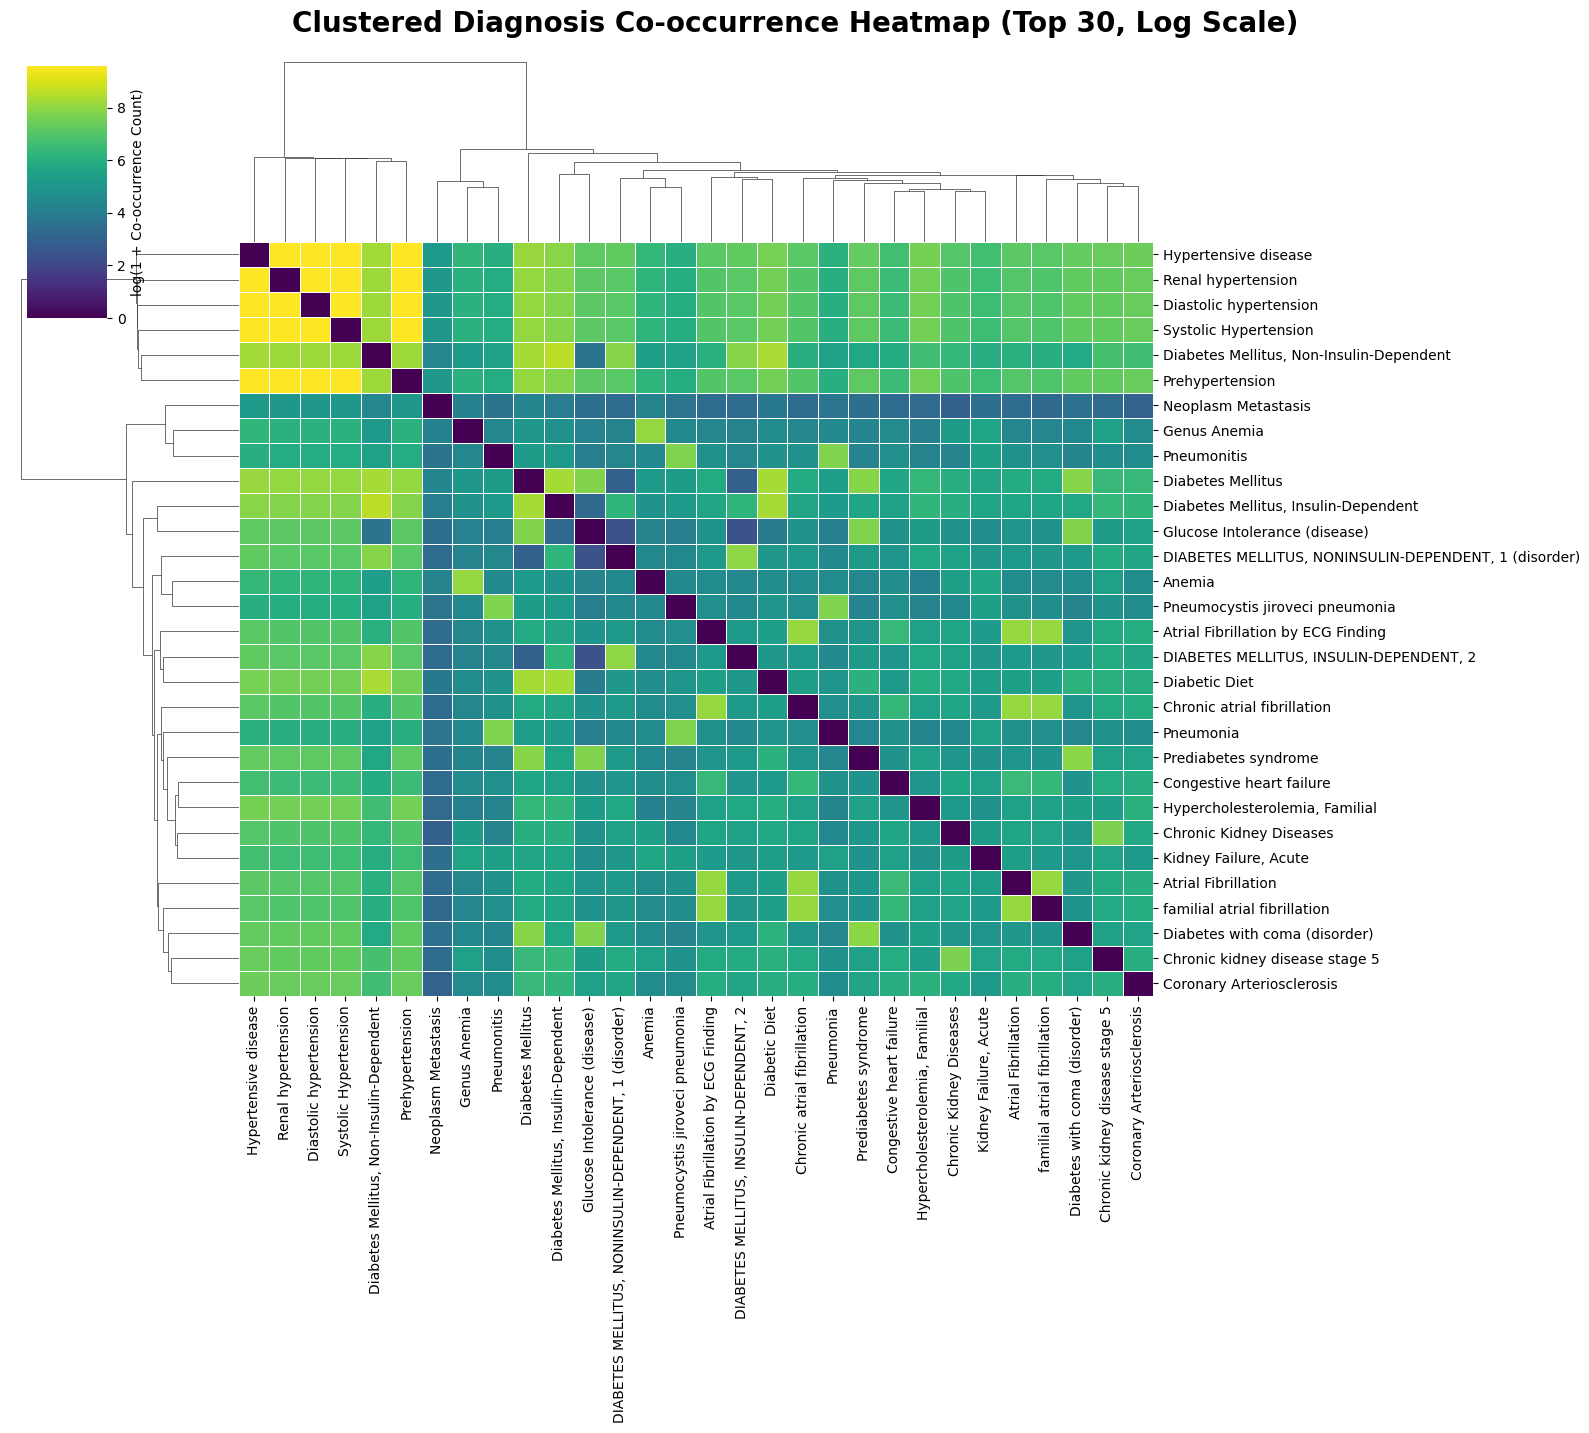

In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Log transform
log_scaled_matrix = np.log1p(cooccurrence_df_k)

# Create clustered heatmap
g = sns.clustermap(
    log_scaled_matrix,
    cmap='viridis',
    figsize=(16, 14),
    metric='euclidean',
    method='ward',
    linewidths=0.5,
    cbar_kws={'label': 'log(1 + Co-occurrence Count)'},
)

# Add a title to the whole figure (note: suptitle is used on the ClusterGrid figure)
g.fig.suptitle("Clustered Diagnosis Co-occurrence Heatmap (Top 30, Log Scale)", y=1.02, fontsize=20, fontweight='bold')

# Save using fig (not ax-based because clustermap doesn't return axes)
g.fig.savefig("clustered_cooccurrence_heatmap_top30.pdf", dpi=300)
# plt.close(g.fig)  # Optional: free memory
